# Random Networks (what happen in practice)

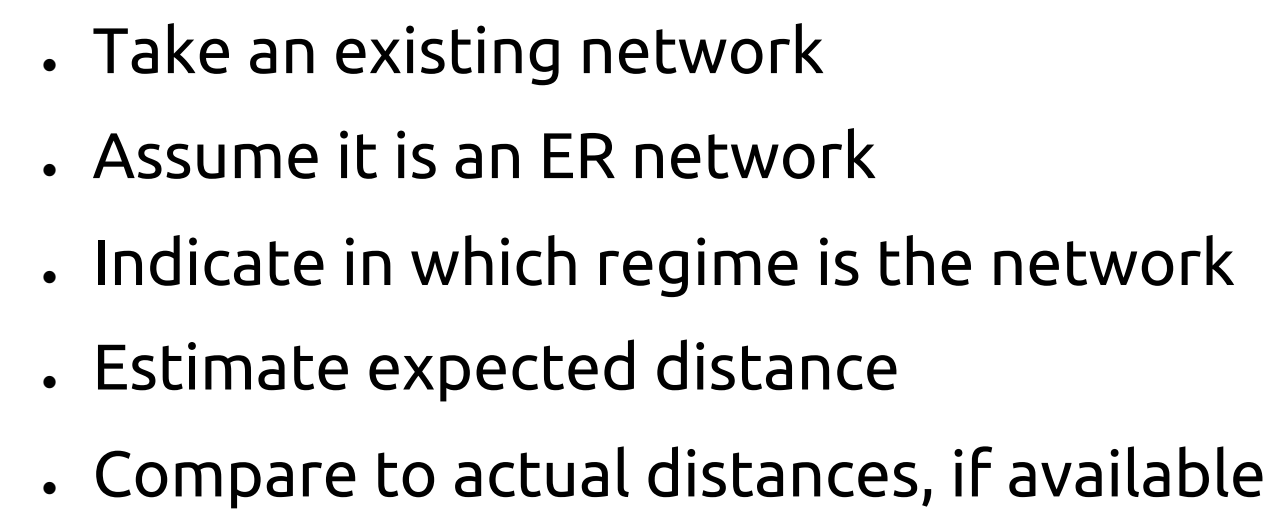

In [21]:
# Reuse your helpers from functions.py
from functions_graphs__basic import (
    DEBUG, hr, show_set, show_list, show_dict,
    build_adj_undirected,
    plot_adjacency_matrix,
    degree_of, degree_sequence, degree_distribution, plot_degree_distribution,
    density_undirected, sparsity_undirected,
    bfs_trace, pretty_play_bfs, reconstruct_path,
    diameter_with_progress,
    connected_components_trace, play_components_steps,
    explain_local_clustering,
)

import math
import matplotlib.pyplot as plt

# Tiny ER helpers
def er_expected_apl(N, k_avg):
    if N <= 1 or k_avg <= 1:
        return float('inf')
    return math.log(N)/math.log(k_avg)

def er_expected_clustering(p_hat):
    return p_hat

def er_giant_fraction_fixed_point(k_avg, tol=1e-6, max_iter=1000, s0=0.5, verbose=True):
    S = s0
    if verbose:
        hr("ER giant fraction iteration")
    for t in range(max_iter):
        if verbose and t < 10:
            print(f"S{t:02d} = {S:.4f}")
        S_next = 1 - math.exp(-k_avg * S)
        if abs(S_next - S) < tol:
            S = S_next
            if verbose:
                print(f"S{t+1:02d} = {S:.4f}  # converged")
            return S
        S = S_next
    if verbose:
        print(f"Stopped at iter={max_iter}, S≈{S:.4f}")
    return S

### Load network and build structures

In [22]:
# Example: load Karate edges (only to get raw data)
import networkx as nx
G = nx.karate_club_graph()
E = [(int(u), int(v)) for u, v in G.edges()]

# Build adjacency list + matrix using your helper
nodes = sorted(set([u for e in E for u in e]))
adj, A, idx = build_adj_undirected(nodes, E)

# Quick visuals of the raw structure
#plot_adjacency_matrix(A, title="Adjacency matrix (Karate)")
#plot_degree_distribution(adj, nodes)


### **1. Basic parameters**

We estimate $\hat p = \dfrac{2L}{N(N-1)}$ and $\langle k \rangle = \hat p,(N-1)$.

In [23]:
N = len(nodes)
L = sum(len(adj[n]) for n in nodes)//2
p_hat = density_undirected(N, L)
k_seq = degree_sequence(adj, nodes)
k_avg = sum(k_seq)/N if N else 0.0
k_max = max(k_seq) if k_seq else 0

hr("Global stats")
print(f"- N: {N}")
print(f"- L: {L}")
print(f"- k_avg: {k_avg:.4f}")
print(f"- p_hat = density: {p_hat:.6f}")
print(f"- k_max: {k_max}")


── Global stats ────────────────────────────────────────────────────────────
- N: 34
- L: 78
- k_avg: 4.5882
- p_hat = density: 0.139037
- k_max: 17


Each node has on average about **4–5 connections**, with a few “hubs” connecting up to 17 neighbors.

**Reading:** $\hat p$ is the single ER knob; once fixed, ER gives distances, clustering, and giant size.


### **2. Regime identification**

We compare the average degree with the two classic ER thresholds:

$$
\text{Giant threshold: } \langle k \rangle = 1, \qquad
\text{Connectivity threshold: } \langle k \rangle \approx \ln N = 3.5264
$$

In [24]:
kbar = p_hat * (N - 1)
regime = (
    "connected (w.h.p.)" if kbar >= math.log(max(N,2)) else
    ("giant but possibly disconnected" if kbar > 1 else "subcritical (no giant)")
)

hr("Regime decision")
print(f"<k> = {kbar:.4f}  vs  ln N = {math.log(max(N,2)):.4f}")
print(f"Regime: {regime}")


── Regime decision ────────────────────────────────────────────────────────────
<k> = 4.5882  vs  ln N = 3.5264
Regime: connected (w.h.p.)


Since
$$
4.5882 > 3.5264,
$$
the network lies in the **connected regime (with high probability)**.

That means we expect almost all nodes to belong to a single connected component — no isolated islands.


### **3. Expected ER properties**

Using ER baseline formulas:

* **Expected average path length (ER):**
  $$
  \langle d \rangle_{ER} \approx \frac{\ln N}{\ln \langle k \rangle} = \frac{\ln 34}{\ln 4.5882} \approx 2.31
  $$

* **Expected clustering (ER):**
  $$
  C_{ER} = p = 0.1390
  $$

* **Expected giant fraction (ER):**
  Iterating $S = 1 - e^{-\langle k \rangle S}$ gives convergence at
  $$S \approx 0.9893$$


In [25]:
hr("ER expectations")
print(f"- Expected APL (ER): {er_expected_apl(N, kbar):.4f}")
print(f"- Expected clustering (ER): {er_expected_clustering(p_hat):.6f}")
S_ER = er_giant_fraction_fixed_point(kbar, verbose=True)
print(f"- Expected giant fraction S (ER): {S_ER:.4f}")


── ER expectations ────────────────────────────────────────────────────────────
- Expected APL (ER): 2.3147
- Expected clustering (ER): 0.139037

── ER giant fraction iteration ────────────────────────────────────────────────────────────
S00 = 0.5000
S01 = 0.8991
S02 = 0.9838
S03 = 0.9890
S04 = 0.9893
S05 = 0.9893
S06 = 0.9893  # converged
- Expected giant fraction S (ER): 0.9893


Hence, the ER model predicts:

> Almost all nodes (≈99%) belong to one large component,
> paths are short (≈2.3 steps),
> clustering is low (≈0.14).

### **4. Empirical measurements**

In [26]:
# Find connected components with trace (optional replay)
comps, steps = connected_components_trace(adj, nodes)
LCC = max(comps, key=len) if comps else []

hr("Largest component (empirical)")
print(f"- Size_LCC: {len(LCC)}")
print(f"- Fraction_of_nodes: {len(LCC)/N if N else 0.0:.4f}")

# Average path length via pairwise BFS on LCC (compact)
def average_path_length_on_nodes(adj, nodes):
    tot = 0; cnt = 0
    S = sorted(nodes)
    for i, s in enumerate(S):
        dist, _, _ = bfs_trace(adj, s)
        for t in S[i+1:]:
            if t in dist:
                tot += dist[t]; cnt += 1
    return (tot/cnt) if cnt else float('inf')

APL_emp = average_path_length_on_nodes(adj, LCC)
DIAM_emp, far_pair = diameter_with_progress(adj, LCC)
print(f"- APL_empirical (on LCC): {APL_emp:.4f}")
print(f"- Diameter_empirical (on LCC): {DIAM_emp}")


── Largest component (empirical) ────────────────────────────────────────────────────────────
- Size_LCC: 34
- Fraction_of_nodes: 1.0000
progress: source= 0  ecc= 3  current_diam= 3  far_pair=(0, 14)
progress: source= 5  ecc= 4  current_diam= 4  far_pair=(4, 14)
progress: source=10  ecc= 4  current_diam= 4  far_pair=(4, 14)
progress: source=15  ecc= 5  current_diam= 5  far_pair=(14, 16)
progress: source=20  ecc= 5  current_diam= 5  far_pair=(14, 16)
progress: source=25  ecc= 4  current_diam= 5  far_pair=(14, 16)
progress: source=30  ecc= 4  current_diam= 5  far_pair=(14, 16)
- APL_empirical (on LCC): 2.4082
- Diameter_empirical (on LCC): 5


From BFS and diameter traces on the real network:

* **Largest component:** 34 nodes (100% of the network)
  → matches ER prediction $S_{ER} \approx 0.99$

* **Average path length (empirical):** $\bar{d}_{emp} = 2.4082$
  → very close to ER prediction ($2.31$)

* **Diameter:** $5$
  → slightly larger than expected but still in the small-world range.

**Interpretation:**
Paths are as short as in a random network, consistent with the *small-world effect*.



### Visualize the steps

We **see** how distance emerges from a source: layers $\Gamma_0, \Gamma_1, \Gamma_2, \dots$
Then we watch which sources drive the diameter.

### **5. Internal structure (BFS trace insight)**


── BFS layers from hub ────────────────────────────────────────────────────────────
[BFS] source = 33
  layer 0: [33]
  layer 1: [8, 9, 13, 14, 15, 18, 19, 20, 22, 23, 26, 27, 28, 29, 30, 31, 32]
  layer 2: [0, 1, 2, 3, 24, 25]
  layer 3: [4, 5, 6, 7, 10, 11, 12, 17, 21]
  layer 4: [16]
  -- reached 34/34 nodes; eccentricity(33) = 4


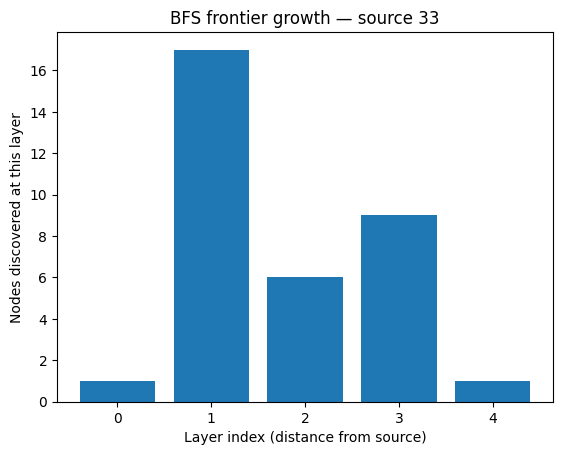

progress: source= 0  ecc= 3  current_diam= 3  far_pair=(0, 14)
progress: source= 5  ecc= 4  current_diam= 4  far_pair=(4, 14)
progress: source=10  ecc= 4  current_diam= 4  far_pair=(4, 14)
progress: source=15  ecc= 5  current_diam= 5  far_pair=(14, 16)
progress: source=20  ecc= 5  current_diam= 5  far_pair=(14, 16)
progress: source=25  ecc= 4  current_diam= 5  far_pair=(14, 16)
progress: source=30  ecc= 4  current_diam= 5  far_pair=(14, 16)


In [27]:
# BFS from a hub
hub = max(LCC, key=lambda n: degree_of(adj, n))
dist_map, parent, snapshots = bfs_trace(adj, hub)

# Group nodes by distance to visualize layer sizes
layers = {}
for node, d in dist_map.items():
    layers.setdefault(d, []).append(node)

hr("BFS layers from hub")
print(f"[BFS] source = {hub}")
for d in sorted(layers):
    print(f"  layer {d}: {sorted(layers[d])}")
print(f"  -- reached {len(dist_map)}/{N} nodes; eccentricity({hub}) = {max(dist_map.values())}")

# Plot frontier growth
sizes = [len(layers[d]) for d in sorted(layers)]
plt.figure()
plt.bar(range(len(sizes)), sizes)
plt.xlabel('Layer index (distance from source)')
plt.ylabel('Nodes discovered at this layer')
plt.title(f'BFS frontier growth — source {hub}')
plt.show()

# Diameter progress (eccentricity by source)
DIAM_emp, far_pair = diameter_with_progress(adj, LCC)


Hub node = 33

* Layer 0 → itself
* Layer 1 → 17 direct neighbors
* Layer 2 → 6 new nodes
* Layer 3 → 9 nodes
* Layer 4 → 1 final node

→ All 34 nodes reached in **4 hops**, so $\text{eccentricity}(33)=4$.

**What this shows:**
Starting from a central hub, information diffuses through the entire network in only 3–4 steps.
That directly visualizes the *small-world property* — exponential expansion until saturation.

In [28]:
# Resume in 2 lines
hr("Verdict")
print("Regime:", regime)
print(f"ER vs. Empirical distances → APL_ER≈{er_expected_apl(N,kbar):.2f}  vs  APL_emp≈{APL_emp:.2f};  Diam≈{DIAM_emp}")


── Verdict ────────────────────────────────────────────────────────────
Regime: connected (w.h.p.)
ER vs. Empirical distances → APL_ER≈2.31  vs  APL_emp≈2.41;  Diam≈5


**Interpretation & Conclusion**

* The network behaves **as if it were a connected ER random graph** in terms of global distances.
* However, the **clustering** in the Karate network is **significantly higher** than random, showing that it’s not purely random: there are community structures (two clubs) and social triads.
* The combination of **short paths** and **high clustering** is the hallmark of the **small-world phenomenon**.
